This file is dedicated to experiments with the different hyperparameters available for the logistic regression.

TODO

Explore more the proportion of attention. 


In [5]:
### code to test the hyperparameter C.
# It controls regularization strength.
# High c = weak regularization (weights can be larger, more flexible model, more risk of overfitting)
# Low c = strong regularization (weights forced smaller, simpler model, more risk of underfitting).
# Default is 1.
# I started by exploring with the same 18 features we had talked about in the meeting. 

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

df_donors = pd.read_csv('Donors_dataset.csv')

num_features = [
    "RECENT_AVG_GIFT_AMT", "LAST_GIFT_AMT", "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT", "LIFETIME_MAX_GIFT_AMT", "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT", "MONTHS_SINCE_FIRST_GIFT", "LIFETIME_GIFT_COUNT",
    "PER_CAPITA_INCOME", "MEDIAN_HOUSEHOLD_INCOME",
    "RECENT_RESPONSE_PROP", "RECENT_RESPONSE_COUNT", "WEALTH_RATING"
]


cat_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"
]

C = 100
penalty = 'l2' # or l1
solver = 'liblinear'


# Default parameters are:
# C = 1
# pnalty = l2
# solver = 'liblinear'

# set c value. It controls regularization strength.
# High c = weak regularization (weights can be larger, more flexible model, more risk of overfitting)
# Low c = strong regularization (weights forced smaller, simpler model, more risk of underfitting).
# Default is 1.

label_balance = 'balanced'
# you can make your balance between the two labels by adding a new label_weight as a dictionary:
# label_weight = {0: 1.0, 1: 2.0}



# Keeping only TARGET_B + selected predictors
df_B = df_donors[['TARGET_B'] + num_features + cat_features].copy() #copies the chosen features to df_B

df_B['WEALTH_RATING_unknown'] = df_B['WEALTH_RATING'].isna().astype(int)

# 2) Fill missing WEALTH_RATING with the median
wr_median = df_B['WEALTH_RATING'].median()
df_B['WEALTH_RATING'] = df_B['WEALTH_RATING'].fillna(wr_median)

# check missing values
print(df_B.isna().sum())

# 3) One-hot encode only the categorical features
df_B_encoded = pd.get_dummies(df_B, columns=cat_features, drop_first=True)

# 4) Final X and y
X_B = df_B_encoded.drop('TARGET_B', axis=1)
y_B = df_B_encoded['TARGET_B']




X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B_full, y_B_full, random_state=42
)

# Fit logistic regression
logreg_full = LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=100000000, class_weight=label_balance)
logreg_full.fit(X_B_train, y_B_train)

# Accuracy
print("Train set score (Accuracy) =", logreg_full.score(X_B_train, y_B_train))
print("Test set score (Accuracy)  =", logreg_full.score(X_B_test, y_B_test))

print()

TARGET_B                    0
RECENT_AVG_GIFT_AMT         0
LAST_GIFT_AMT               0
LIFETIME_AVG_GIFT_AMT       0
RECENT_AVG_CARD_GIFT_AMT    0
LIFETIME_MAX_GIFT_AMT       0
NUMBER_PROM_12              0
MONTHS_SINCE_LAST_GIFT      0
MONTHS_SINCE_FIRST_GIFT     0
LIFETIME_GIFT_COUNT         0
PER_CAPITA_INCOME           0
MEDIAN_HOUSEHOLD_INCOME     0
RECENT_RESPONSE_PROP        0
RECENT_RESPONSE_COUNT       0
WEALTH_RATING               0
URBANICITY                  0
SES                         0
DONOR_GENDER                0
RECENCY_STATUS_96NK         0
WEALTH_RATING_unknown       0
dtype: int64
Train set score (Accuracy) = 0.5860692408286875
Test set score (Accuracy)  = 0.5791864546768531



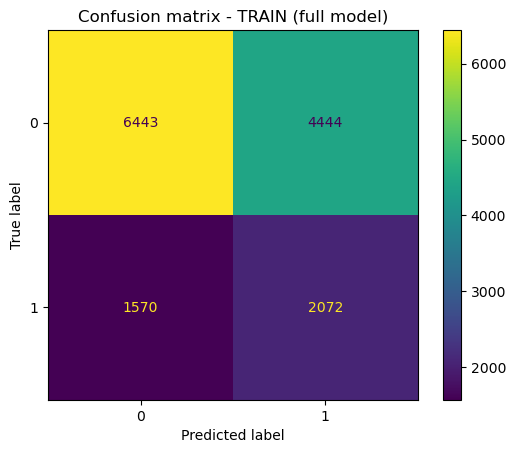

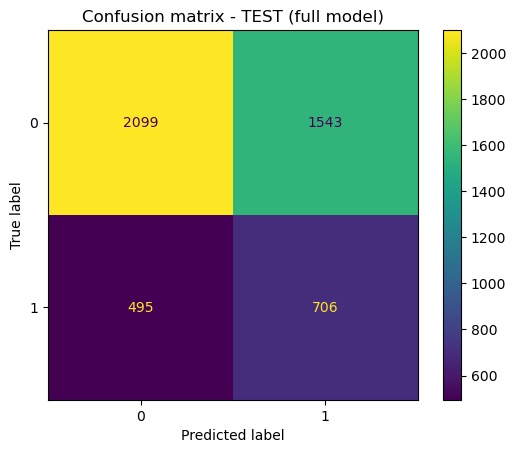


TRAIN classification report:
              precision    recall  f1-score   support

           0       0.80      0.59      0.68     10887
           1       0.32      0.57      0.41      3642

    accuracy                           0.59     14529
   macro avg       0.56      0.58      0.54     14529
weighted avg       0.68      0.59      0.61     14529

TEST classification report:
              precision    recall  f1-score   support

           0       0.81      0.58      0.67      3642
           1       0.31      0.59      0.41      1201

    accuracy                           0.58      4843
   macro avg       0.56      0.58      0.54      4843
weighted avg       0.69      0.58      0.61      4843



In [6]:
### Confusion matrices. The results are very bad. The problem might be related to data unbalance: almost 75% are non donors.

# Predictions
y_B_train_pred = logreg_full.predict(X_B_train)
y_B_test_pred  = logreg_full.predict(X_B_test)

# TRAIN confusion matrix
cm_train_full = confusion_matrix(y_B_train, y_B_train_pred)
disp_train_full = ConfusionMatrixDisplay(confusion_matrix=cm_train_full,
                                         display_labels=logreg_full.classes_)
disp_train_full.plot()
plt.title("Confusion matrix - TRAIN (full model)")
plt.show()

# TEST confusion matrix
cm_test_full = confusion_matrix(y_B_test, y_B_test_pred)
disp_test_full = ConfusionMatrixDisplay(confusion_matrix=cm_test_full,
                                        display_labels=logreg_full.classes_)
disp_test_full.plot()
plt.title("Confusion matrix - TEST (full model)")
plt.show()


### Evaluation metrics

from sklearn.metrics import f1_score, classification_report

# F1 for class 1 (donors)
f1_train = f1_score(y_B_train, y_B_train_pred, pos_label=1)
f1_test  = f1_score(y_B_test, y_B_test_pred, pos_label=1)

print("\nTRAIN classification report:")
print(classification_report(y_B_train, y_B_train_pred))

print("TEST classification report:")
print(classification_report(y_B_test, y_B_test_pred))

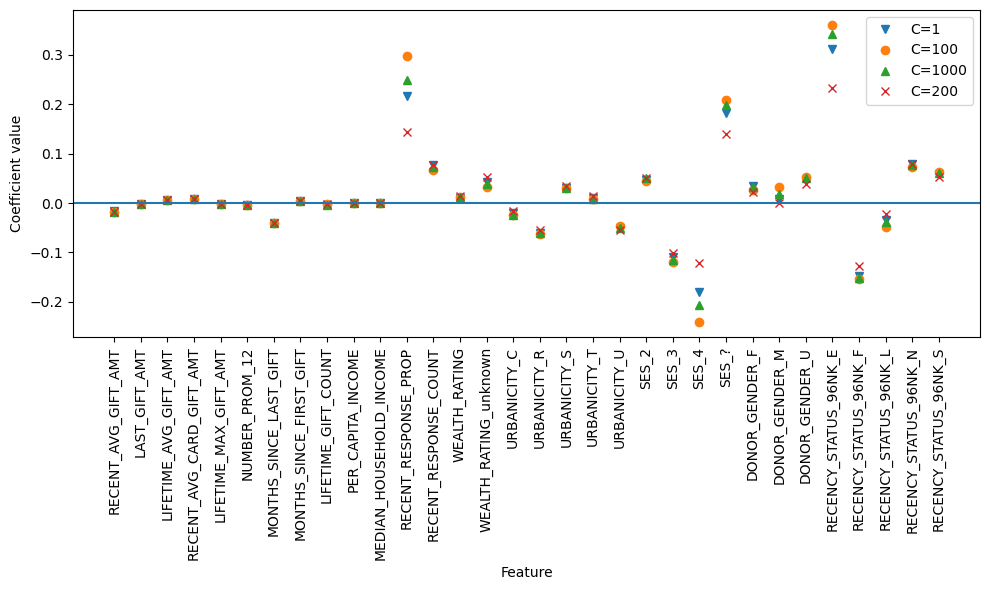

In [7]:
### Testing the effect of the hyperparameter C in the coefficients. 
# C controls regularization strength.
# High c = weak regularization (weights can be larger, more flexible model, more risk of overfitting)
# Low c = strong regularization (weights forced smaller, simpler model, more risk of underfitting).
# Default is 1.
# Results: the value of C seems to have a low impact in most coeficients, both in L1 and in L2. Pratically no impact in L1.
# L1 has particularly bad result -> do not use. It has too many coefificents close to zero. 
# I chose to continue with C = 100, because it was the one that returned higher absolute values for the coeficients.
# It makes sense to want higher coeficients, and more further away from zero, since the current problem is underfitting. 
# saga solver returns very bad values.
# lbfgs had some interesting results and is something to try later. 

# We can test the effect of the C in the coeficients and cross it with the other hyperparameters.   
penalty = 'l2' # or l1
solver = 'liblinear'

# Compare coefficients for different C values
C_values = [1, 100, 1000, 200] # We can add more values of C to this list. 
markers = ['v', 'o', '^', 'x']
models = []

for C_val in C_values:
    clf = LogisticRegression(
        C=C_val,
        penalty=penalty,
        solver=solver,
        max_iter=100000,
        class_weight=label_balance
    )
    clf.fit(X_B_train, y_B_train)
    models.append(clf)

plt.figure(figsize=(10, 6))

for clf, C_val, mark in zip(models, C_values, markers):
    plt.plot(clf.coef_.T, mark, label=f"C={C_val}")

plt.xticks(range(X_B_train.shape[1]), X_B_train.columns, rotation=90)
xlims = plt.xlim()
plt.hlines(0, xlims[0], xlims[1])
plt.xlim(xlims)
plt.ylabel("Coefficient value")
plt.xlabel("Feature")
plt.legend()
plt.tight_layout()
plt.show()



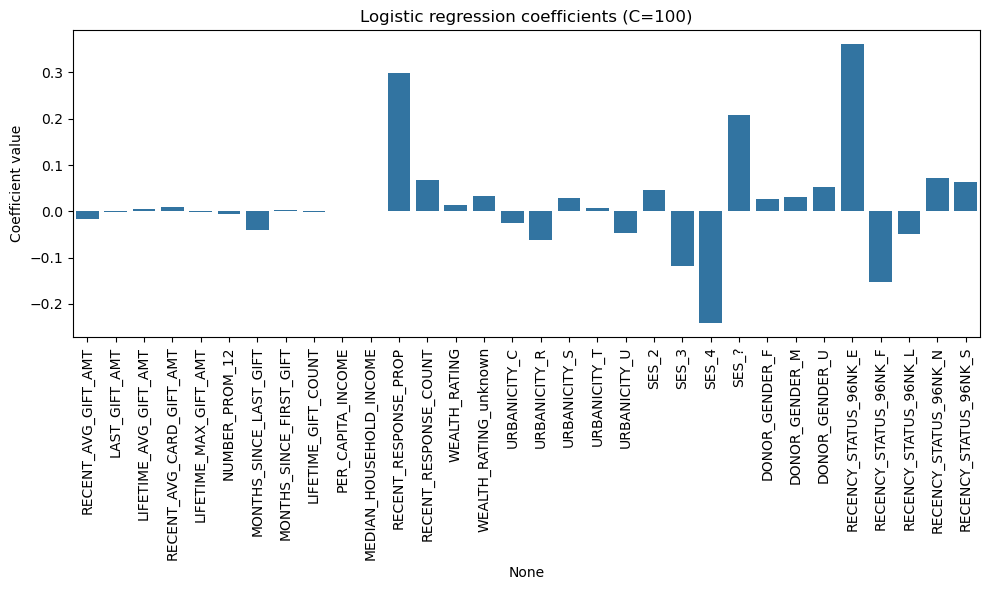

                     feature  coefficient
27     RECENCY_STATUS_96NK_E     0.360955
11      RECENT_RESPONSE_PROP     0.297835
22                     SES_4    -0.240925
23                     SES_?     0.208106
28     RECENCY_STATUS_96NK_F    -0.152860
21                     SES_3    -0.118410
30     RECENCY_STATUS_96NK_N     0.073061
12     RECENT_RESPONSE_COUNT     0.067544
31     RECENCY_STATUS_96NK_S     0.063276
16              URBANICITY_R    -0.062767
26            DONOR_GENDER_U     0.053716
29     RECENCY_STATUS_96NK_L    -0.048163
19              URBANICITY_U    -0.045816
20                     SES_2     0.045544
6     MONTHS_SINCE_LAST_GIFT    -0.039922
14     WEALTH_RATING_unknown     0.032587
25            DONOR_GENDER_M     0.031667
17              URBANICITY_S     0.029831
24            DONOR_GENDER_F     0.026958
15              URBANICITY_C    -0.024530
0        RECENT_AVG_GIFT_AMT    -0.017504
13             WEALTH_RATING     0.012858
3   RECENT_AVG_CARD_GIFT_AMT     0

In [7]:
# Presents the coefficients of the model for each feature.  

import seaborn as sns
import pandas as pd


plt.figure(figsize=(10, 6))
sns.barplot(x=X_B_train.columns, y=logreg_full.coef_.flatten())
plt.xticks(rotation=90)
plt.ylabel("Coefficient value")
plt.title("Logistic regression coefficients (C=100)")
plt.tight_layout()
plt.show()



coef_table = pd.DataFrame({
    "feature": X_B_train.columns,
    "coefficient": logreg_full.coef_.flatten()
})

# Optional: sort by absolute value of coefficient
coef_table["abs_coeff"] = coef_table["coefficient"].abs()
coef_table = coef_table.sort_values("abs_coeff", ascending=False).drop(columns="abs_coeff")

print(coef_table)






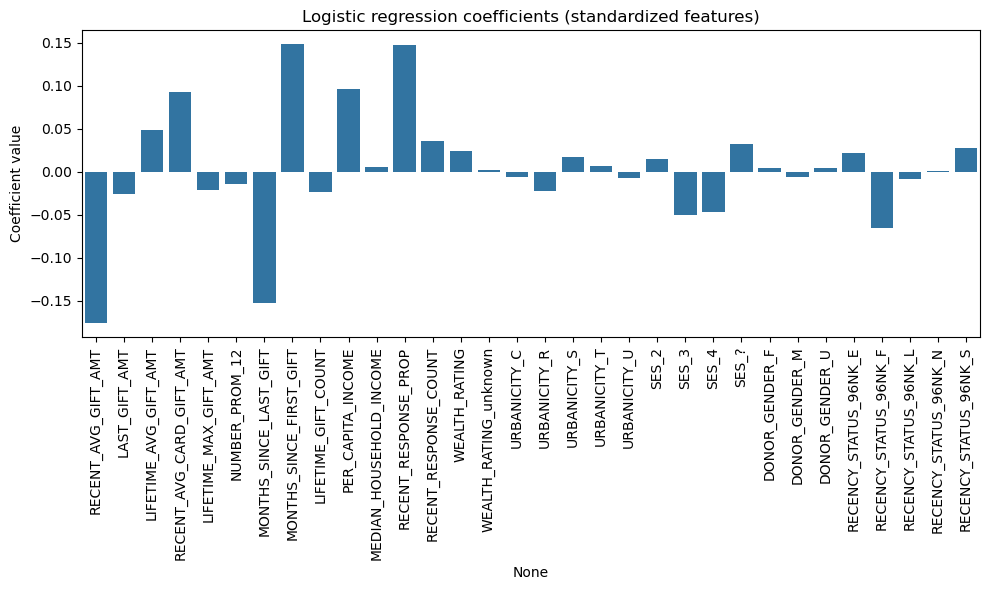

                     feature  coefficient
0        RECENT_AVG_GIFT_AMT    -0.175997
6     MONTHS_SINCE_LAST_GIFT    -0.153014
7    MONTHS_SINCE_FIRST_GIFT     0.148166
11      RECENT_RESPONSE_PROP     0.146739
9          PER_CAPITA_INCOME     0.096530
3   RECENT_AVG_CARD_GIFT_AMT     0.092132
28     RECENCY_STATUS_96NK_F    -0.065223
21                     SES_3    -0.050494
2      LIFETIME_AVG_GIFT_AMT     0.048648
22                     SES_4    -0.046406
12     RECENT_RESPONSE_COUNT     0.035460
23                     SES_?     0.031633
31     RECENCY_STATUS_96NK_S     0.027020
1              LAST_GIFT_AMT    -0.026122
13             WEALTH_RATING     0.024559
8        LIFETIME_GIFT_COUNT    -0.023956
16              URBANICITY_R    -0.022729
27     RECENCY_STATUS_96NK_E     0.021346
4      LIFETIME_MAX_GIFT_AMT    -0.021005
17              URBANICITY_S     0.017161
20                     SES_2     0.015214
5             NUMBER_PROM_12    -0.014306
29     RECENCY_STATUS_96NK_L    -0

In [8]:
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Standardize features (fit on train, transform both)
scaler = StandardScaler()
X_B_train_std = scaler.fit_transform(X_B_train)
X_B_test_std  = scaler.transform(X_B_test)

# Refit logistic regression on standardized data
logreg_full_std = LogisticRegression(
    C=C,
    penalty=penalty,
    solver=solver,
    max_iter=100000000,
    class_weight=label_balance
)
logreg_full_std.fit(X_B_train_std, y_B_train)

# Plot coefficients (standardized)
plt.figure(figsize=(10, 6))
sns.barplot(x=X_B_train.columns, y=logreg_full_std.coef_.flatten())
plt.xticks(rotation=90)
plt.ylabel("Coefficient value")
plt.title("Logistic regression coefficients (standardized features)")
plt.tight_layout()
plt.show()

# Table of coefficients, sorted by |coef|
coef_table = pd.DataFrame({
    "feature": X_B_train.columns,
    "coefficient": logreg_full_std.coef_.flatten()
})

coef_table["abs_coeff"] = coef_table["coefficient"].abs()
coef_table = coef_table.sort_values("abs_coeff", ascending=False).drop(columns="abs_coeff")

print(coef_table)
